In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/heart.csv'
df = pd.read_csv(file_path)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


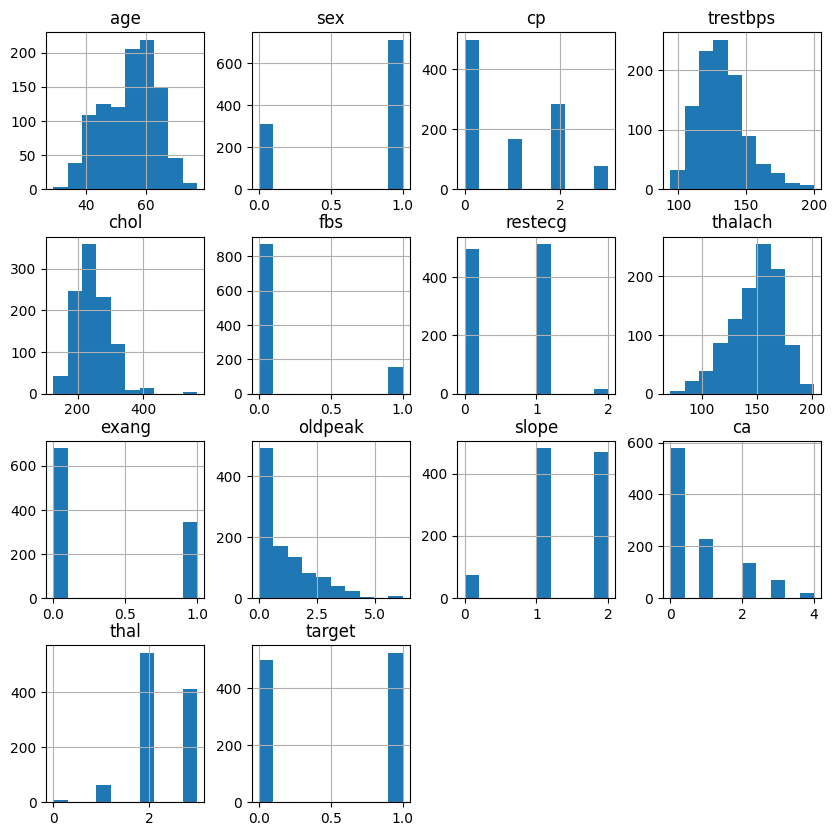

In [ ]:
df.hist(figsize=(10, 10))
plt.show()

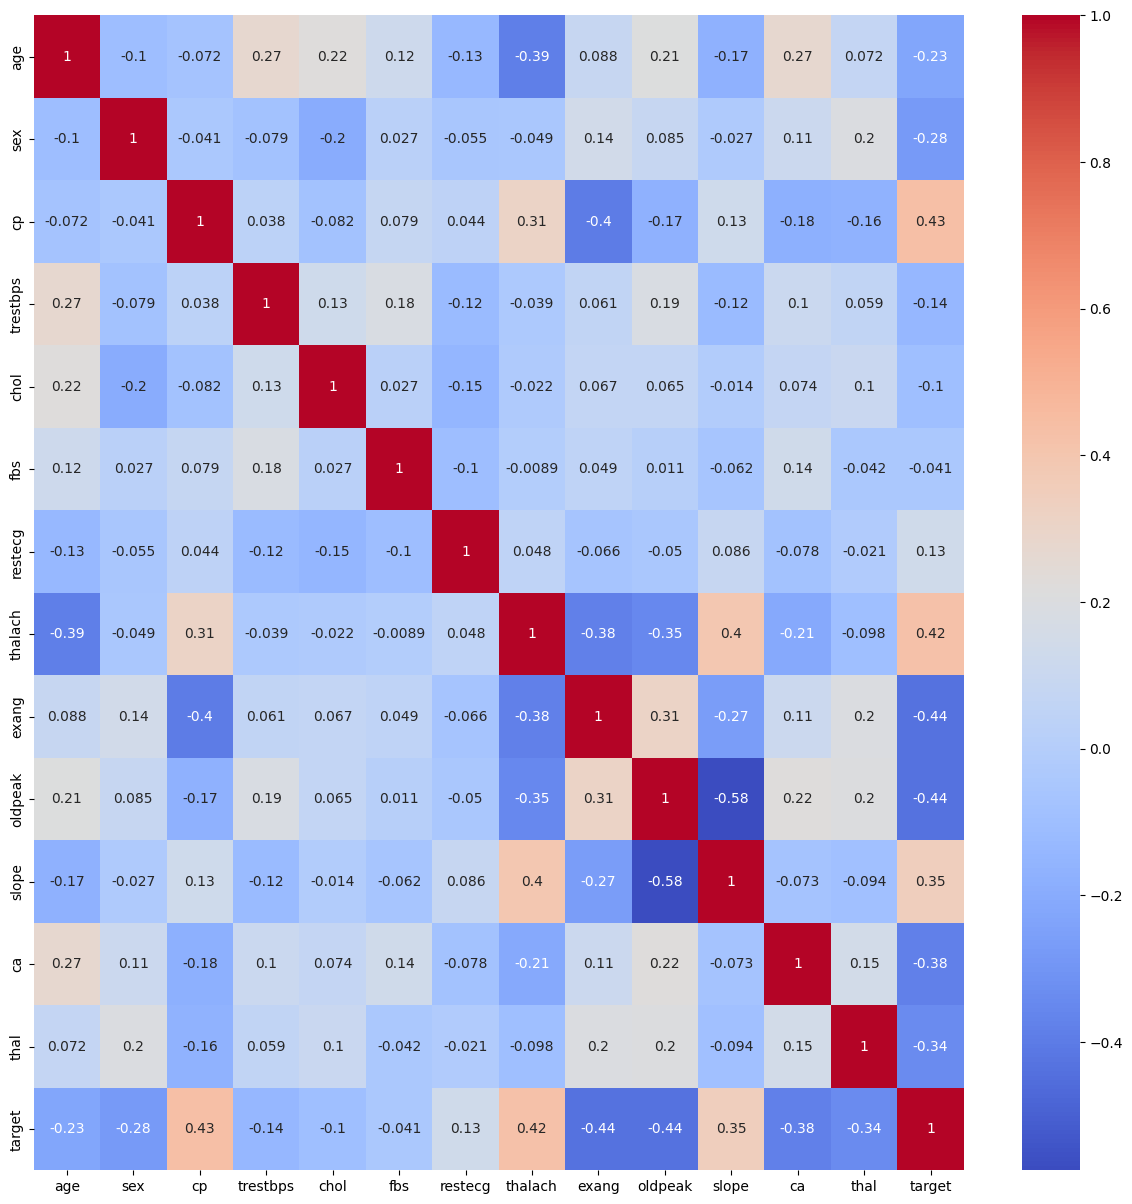

In [ ]:
plt.figure(figsize=(15,15))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap = 'coolwarm')
plt.show()

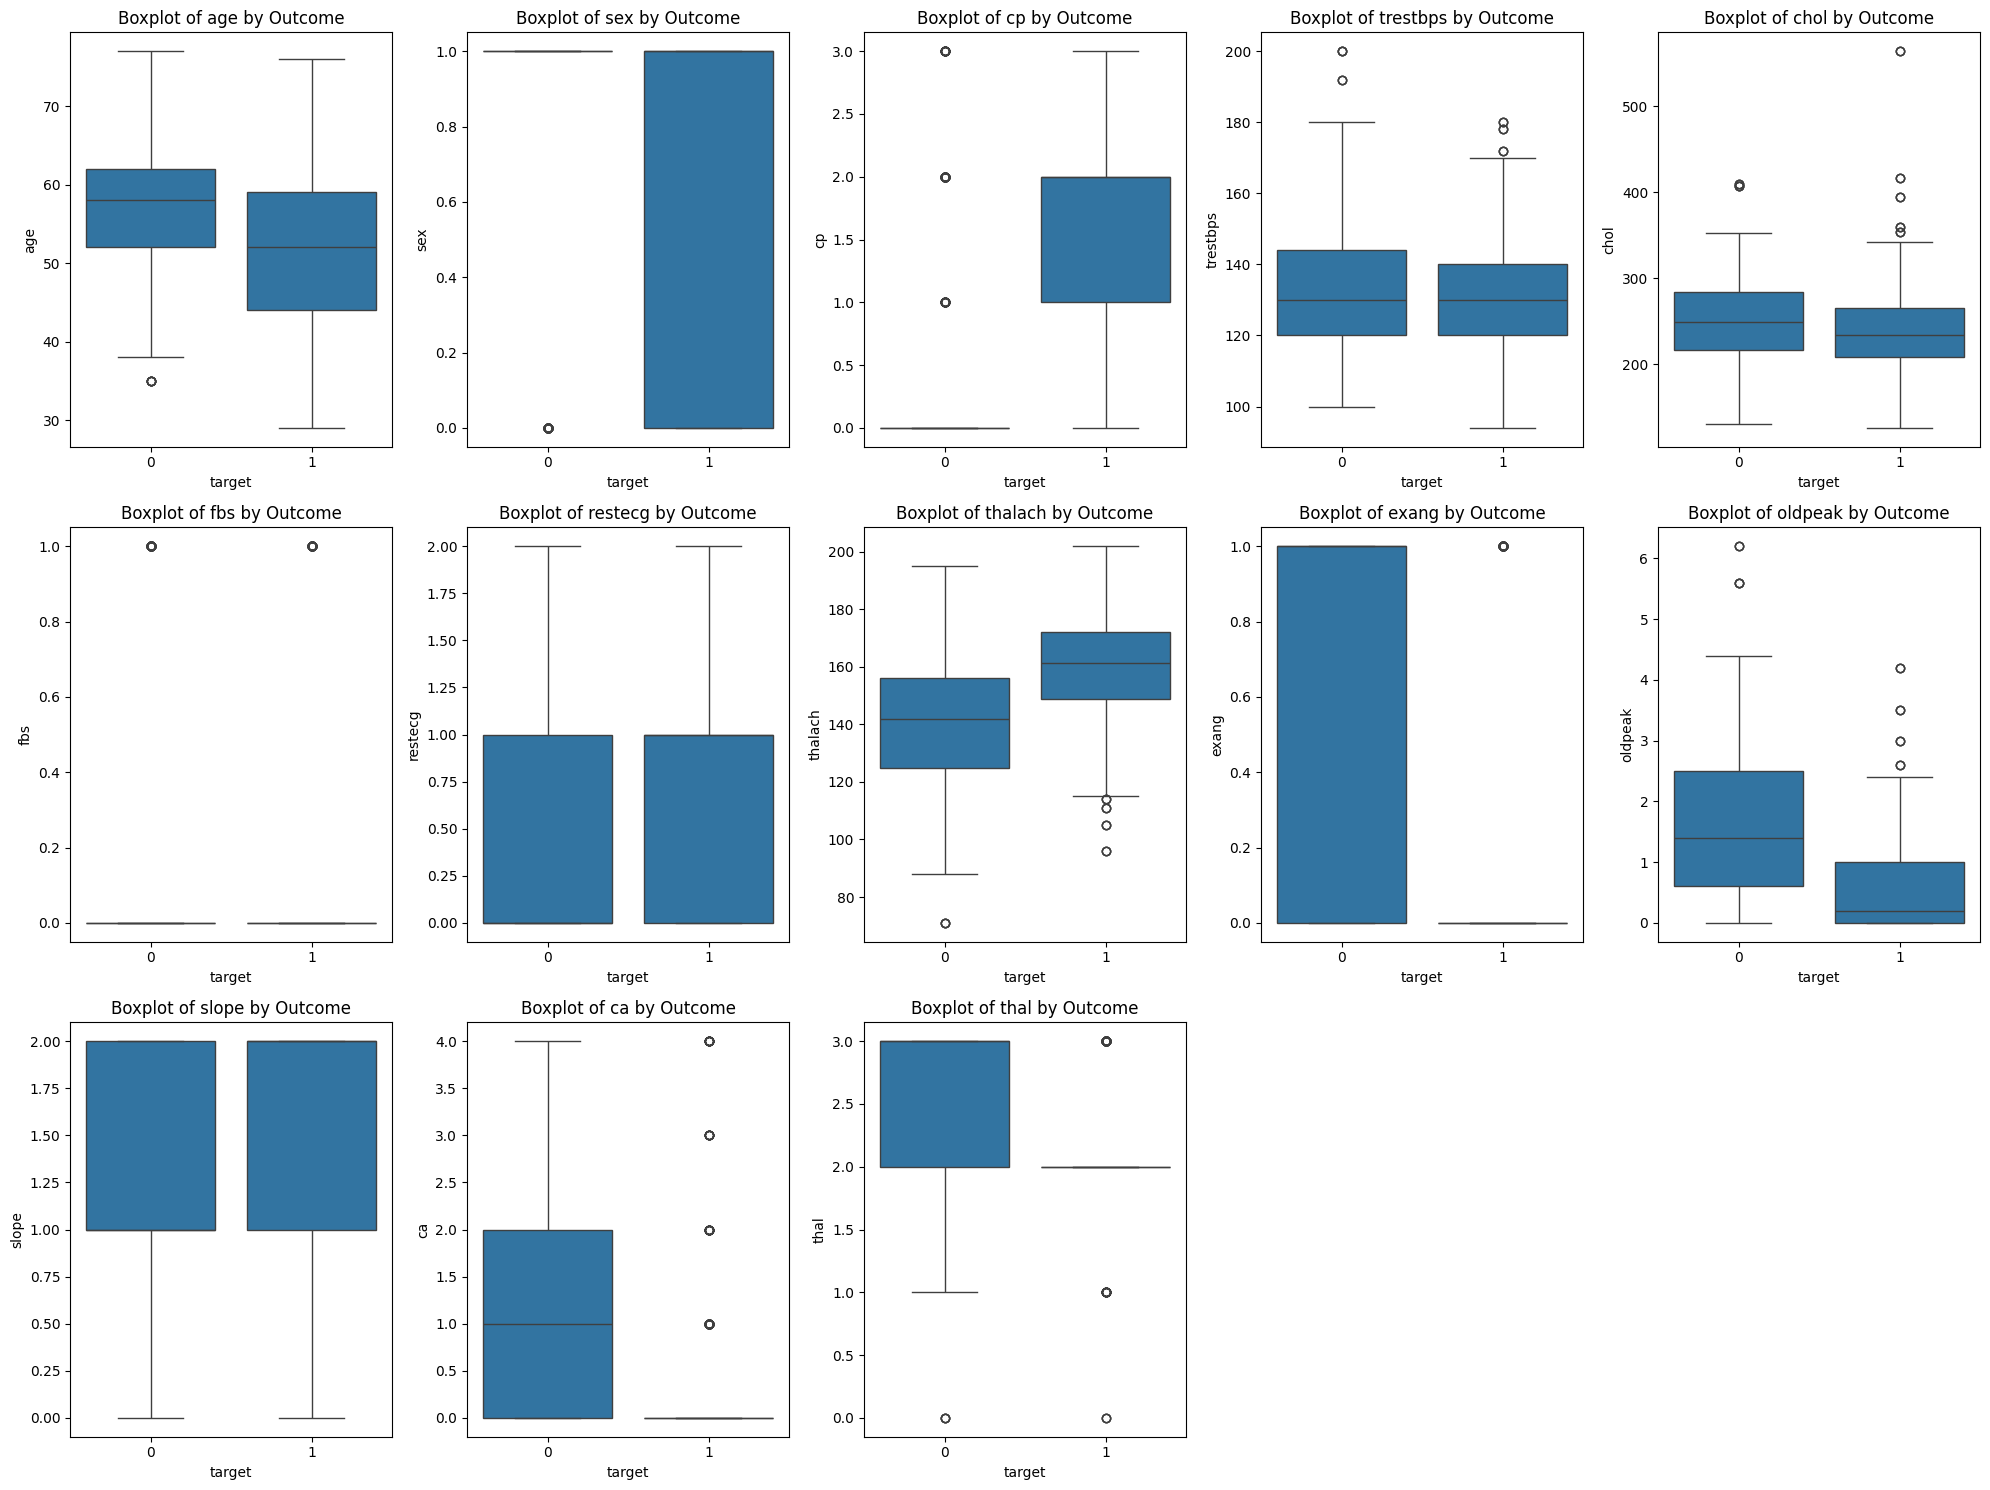

In [ ]:
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach','exang','oldpeak','slope','ca','thal']
plt.figure(figsize=(20,15))
for i,feature in enumerate(features, 1):
  plt.subplot(3, 5, i)
  sns.boxplot(x='target', y= feature, data=df)
  plt.title(f'Boxplot of {feature} by Outcome')

plt.tight_layout()
plt.show()

In [ ]:
x = df.drop('target',axis=1)
y = df['target']

In [ ]:
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train, y_train)

LogisticRegression()

In [ ]:
y_pred = lr.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
print("Logistic Regression Accuracy: ")
accuracy_score(y_test, y_pred)

Logistic Regression Accuracy: 


0.7804878048780488

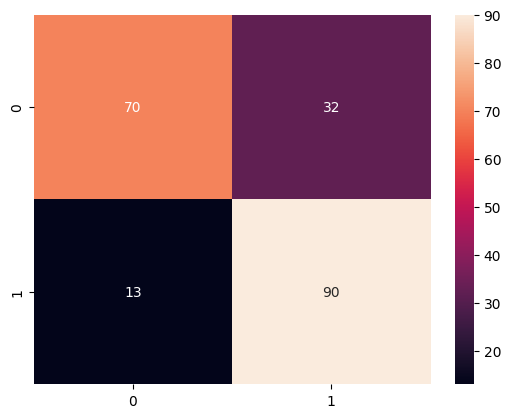

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)
plt.show()

In [ ]:
while True:
 input_values = []
 for col in x.columns:
   val = float(input(f"Enter {col}: "))
   input_values.append(val)

 features_to_predict = np.array(input_values).reshape(1,-1)
 features_scaled = scaler.transform(features_to_predict)

 prediction = lr.predict(features_scaled)
 if(prediction[0] ==1):
   print("1")
 else:
   print("0")